In [2]:
import pandas as pd 

df = pd.read_excel('Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Basic stats and data quality overview
print("=== Basic info ===")
print(df.info())

print("\n=== Summary stats (numeric) ===")
print(df.describe())

print("\n=== Summary stats (including non-numeric) ===")
print(df.describe(include='all'))

print("\n=== Missing values per column ===")
print(df.isna().sum())

print("\n=== Duplicate rows ===")
print("Number of duplicate rows:", df.duplicated().sum())

print("\n=== Date range ===")
print("Min InvoiceDate:", df['InvoiceDate'].min())
print("Max InvoiceDate:", df['InvoiceDate'].max())

print("\n=== Unique counts ===")
print("Number of rows:", len(df))
print("Unique invoices:", df['InvoiceNo'].nunique())
print("Unique products (StockCode):", df['StockCode'].nunique())
print("Unique customers:", df['CustomerID'].nunique())
print("Unique countries:", df['Country'].nunique())

print("\n=== Suspicious / data-quality related values ===")
print("Rows with missing CustomerID:", df['CustomerID'].isna().sum())
print("Rows with negative Quantity (returns):", (df['Quantity'] < 0).sum())
print("Rows with zero or negative UnitPrice:", (df['UnitPrice'] <= 0).sum())

=== Basic info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

=== Summary stats (numeric) ===
            Quantity                    InvoiceDate      UnitPrice  \
count  541909.000000                         541909  541909.000000   
mean        9.552250  2011-07-04 13:34:57.156386048       4.611114   
min    -80995.000000            2010-12-0

In [4]:
# Data cleaning: remove duplicates, handle missing values, cancellations/returns, and create Revenue

# Work on a copy of the original dataframe to preserve raw data
df_clean = df.copy()

# Basic statistics before cleaning
print("=== BEFORE CLEANING ===")
print("Rows:", len(df_clean))
print("Unique invoices:", df_clean['InvoiceNo'].nunique())
print("Unique customers (non-null):", df_clean['CustomerID'].nunique())
print("Total quantity:", df_clean['Quantity'].sum())
print("Total revenue (Quantity * UnitPrice, including returns):", (df_clean['Quantity'] * df_clean['UnitPrice']).sum())

# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# Drop rows with missing critical values (customer and description)
df_clean = df_clean.dropna(subset=['CustomerID', 'Description'])

# Create Revenue column (can be negative for returns before filtering)
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Identify cancelled invoices (InvoiceNo starting with 'C')
cancel_mask = df_clean['InvoiceNo'].astype(str).str.startswith('C')

# Identify returns (negative quantities)
return_mask = df_clean['Quantity'] < 0

# Save cancelled/returned transactions separately for reference
df_returns = df_clean[cancel_mask | return_mask].copy()

# For main analysis, exclude cancelled invoices
df_clean = df_clean[~cancel_mask]

# Keep only positive quantities and prices for the main analysis
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Recompute Revenue after filters (should now be strictly positive)
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Basic statistics after cleaning
print("\n=== AFTER CLEANING (df_clean) ===")
print("Rows:", len(df_clean))
print("Unique invoices:", df_clean['InvoiceNo'].nunique())
print("Unique customers (non-null):", df_clean['CustomerID'].nunique())
print("Total quantity:", df_clean['Quantity'].sum())
print("Total revenue:", df_clean['Revenue'].sum())

# Summary of cancelled/returned transactions
print("\n=== CANCELLED / RETURNED TRANSACTIONS (df_returns) ===")
print("Rows:", len(df_returns))
print("Unique invoices:", df_returns['InvoiceNo'].nunique())
print("Total quantity (can be negative):", df_returns['Quantity'].sum())
print("Total revenue (can be negative):", (df_returns['Quantity'] * df_returns['UnitPrice']).sum())

=== BEFORE CLEANING ===
Rows: 541909
Unique invoices: 25900
Unique customers (non-null): 4372
Total quantity: 5176450
Total revenue (Quantity * UnitPrice, including returns): 9747747.934

=== AFTER CLEANING (df_clean) ===
Rows: 392692
Unique invoices: 18532
Unique customers (non-null): 4338
Total quantity: 5152002
Total revenue: 8887208.894000001

=== CANCELLED / RETURNED TRANSACTIONS (df_returns) ===
Rows: 8872
Unique invoices: 3654
Total quantity (can be negative): -273035
Total revenue (can be negative): -608689.47


In [7]:
# Sales & revenue trends, geographic distribution, top products, and average order value

# 1. Sales & revenue trends over time

df_time = df_clean.copy()
df_time['InvoiceDate_date'] = df_time['InvoiceDate'].dt.date
df_time['InvoiceMonth'] = df_time['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

# Daily sales and revenue
daily_sales = df_time.groupby('InvoiceDate_date').agg(
    daily_revenue=('Revenue', 'sum'),
    daily_quantity=('Quantity', 'sum'),
    daily_orders=('InvoiceNo', 'nunique')
).reset_index()

# Monthly sales and revenue
monthly_sales = df_time.groupby('InvoiceMonth').agg(
    monthly_revenue=('Revenue', 'sum'),
    monthly_quantity=('Quantity', 'sum'),
    monthly_orders=('InvoiceNo', 'nunique')
).reset_index()

print("=== DAILY SALES & REVENUE (HEAD) ===")
print(daily_sales.head())

print("\n=== MONTHLY SALES & REVENUE ===")
print(monthly_sales)

# 2. Geographic distribution (revenue, sales, and order value by country)

orders = df_clean.groupby('InvoiceNo').agg(
    OrderDate=('InvoiceDate', 'min'),
    Country=('Country', 'first'),
    CustomerID=('CustomerID', 'first'),
    OrderRevenue=('Revenue', 'sum'),
    OrderQuantity=('Quantity', 'sum')
).reset_index()

geo_summary = orders.groupby('Country').agg(
    total_revenue=('OrderRevenue', 'sum'),
    total_orders=('InvoiceNo', 'nunique'),
    total_quantity=('OrderQuantity', 'sum'),
    avg_order_value=('OrderRevenue', 'mean'),
    avg_items_per_order=('OrderQuantity', 'mean')
).reset_index().sort_values('total_revenue', ascending=False)

print("\n=== GEOGRAPHIC DISTRIBUTION (ORDERS BY COUNTRY) ===")
print(geo_summary)

# 3. Top performing products

product_summary = df_clean.groupby(['StockCode', 'Description'], dropna=False).agg(
    total_revenue=('Revenue', 'sum'),
    total_quantity=('Quantity', 'sum'),
    order_lines=('InvoiceNo', 'count'),
    unique_invoices=('InvoiceNo', 'nunique')
).reset_index().sort_values('total_revenue', ascending=False)

top_10_products_by_revenue = product_summary.head(10)
top_10_products_by_quantity = product_summary.sort_values('total_quantity', ascending=False).head(10)

print("\n=== TOP 10 PRODUCTS BY REVENUE ===")
print(top_10_products_by_revenue)

print("\n=== TOP 10 PRODUCTS BY QUANTITY SOLD ===")
print(top_10_products_by_quantity)

# 4. Average order value (overall and over time)

overall_aov = orders['OrderRevenue'].mean()
print("\n=== OVERALL AVERAGE ORDER VALUE (AOV) ===")
print(overall_aov)

orders['OrderDate_date'] = orders['OrderDate'].dt.date
orders['OrderMonth'] = orders['OrderDate'].dt.to_period('M').dt.to_timestamp()

daily_aov = orders.groupby('OrderDate_date')['OrderRevenue'].mean().reset_index(name='AOV')
monthly_aov = orders.groupby('OrderMonth')['OrderRevenue'].mean().reset_index(name='AOV')

print("\n=== DAILY AOV (FIRST 10 DAYS) ===")
print(daily_aov.head(10))

print("\n=== MONTHLY AOV ===")
print(monthly_aov)

=== DAILY SALES & REVENUE (HEAD) ===
  InvoiceDate_date  daily_revenue  daily_quantity  daily_orders
0       2010-12-01       46192.49           24114           121
1       2010-12-02       47197.57           31077           137
2       2010-12-03       23876.63           11798            57
3       2010-12-05       31361.28           16241            87
4       2010-12-06       31009.33           16115            94

=== MONTHLY SALES & REVENUE ===
   InvoiceMonth  monthly_revenue  monthly_quantity  monthly_orders
0    2010-12-01       570422.730            311048            1400
1    2011-01-01       568101.310            348473             987
2    2011-02-01       446084.920            265027             997
3    2011-03-01       594081.760            347582            1321
4    2011-04-01       468374.331            291366            1149
5    2011-05-01       677355.150            372864            1555
6    2011-06-01       660046.050            363014            1393
7    2011-

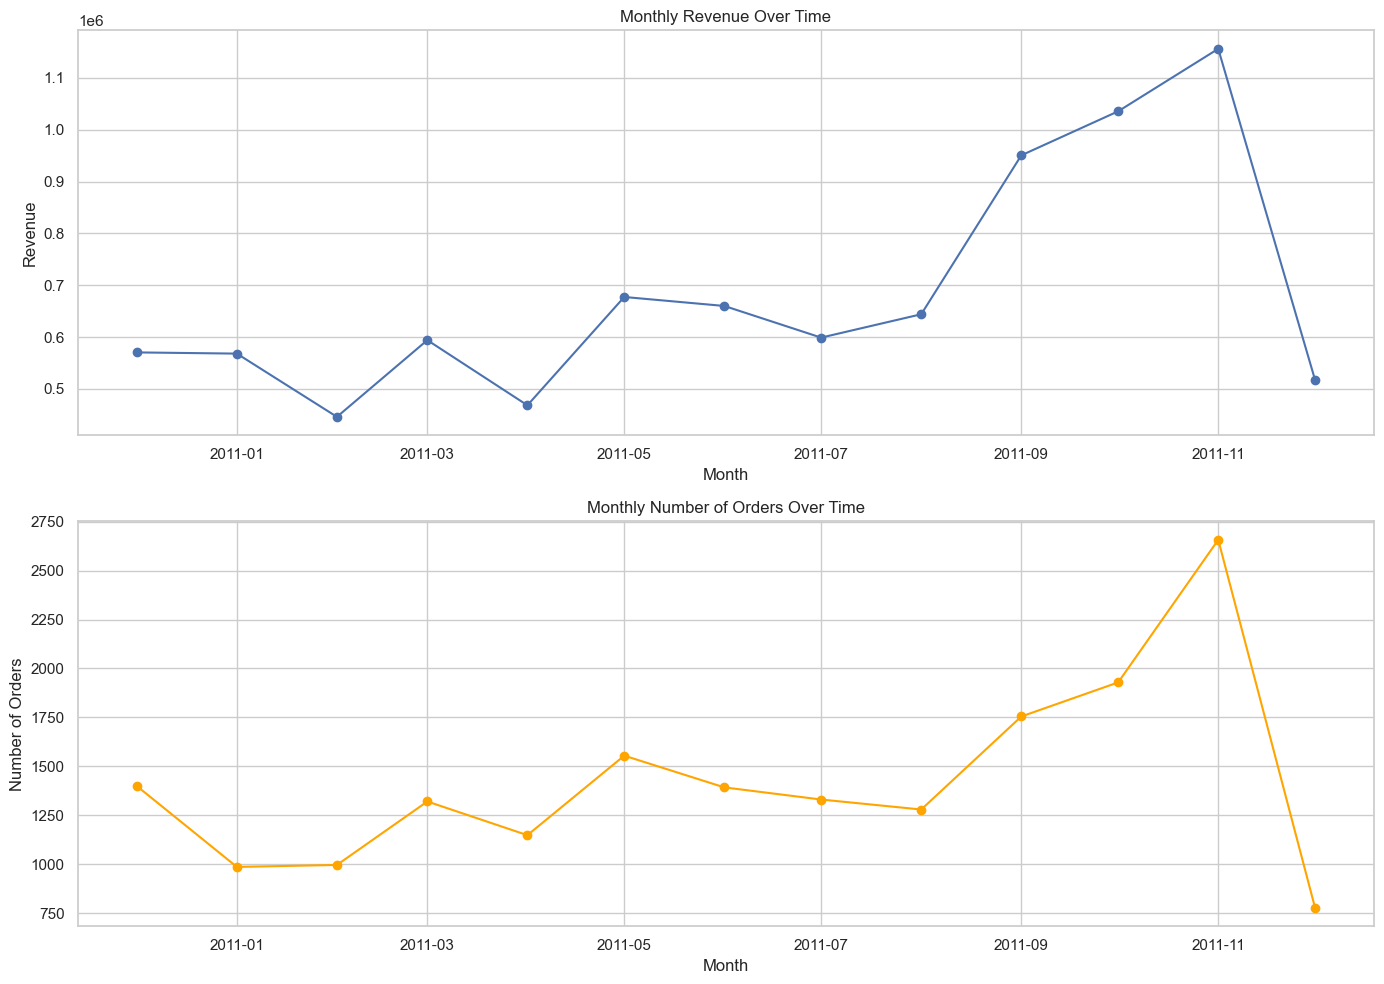

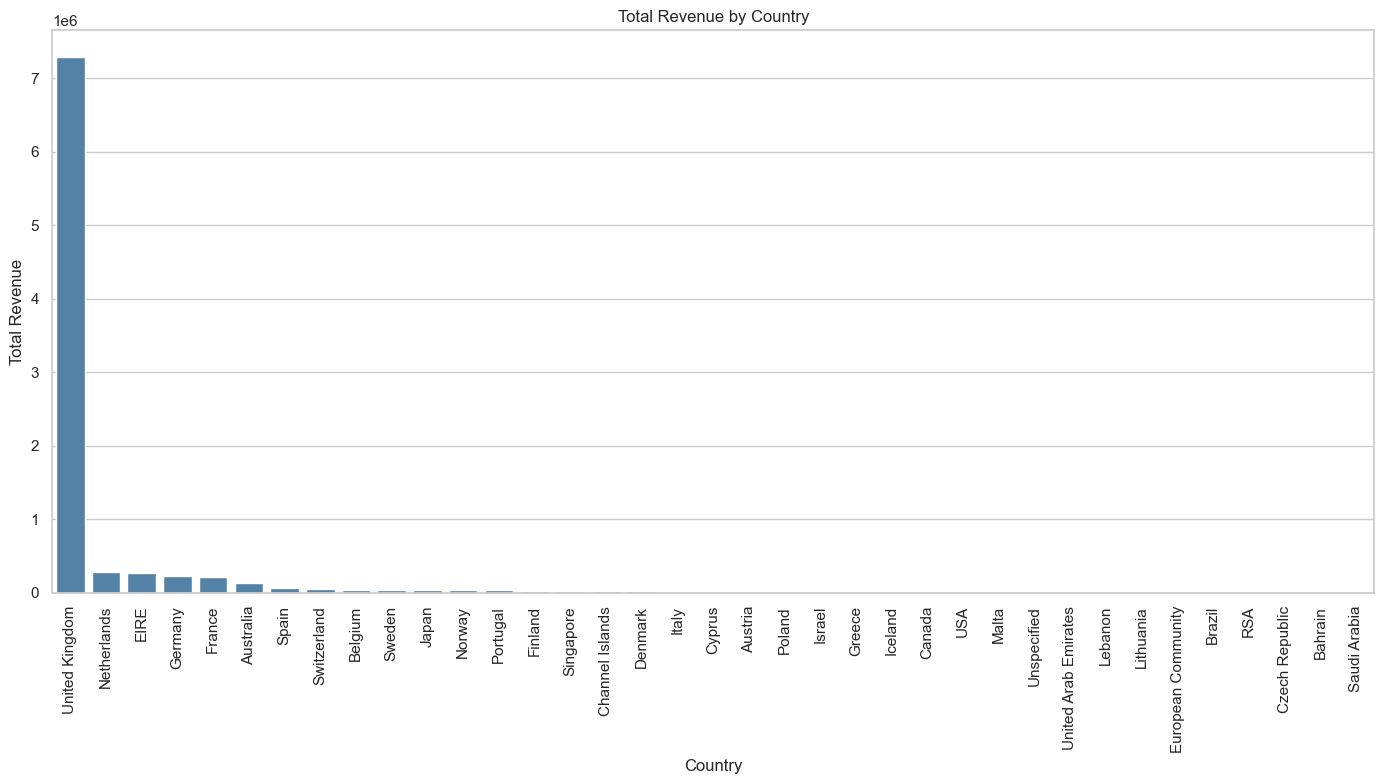

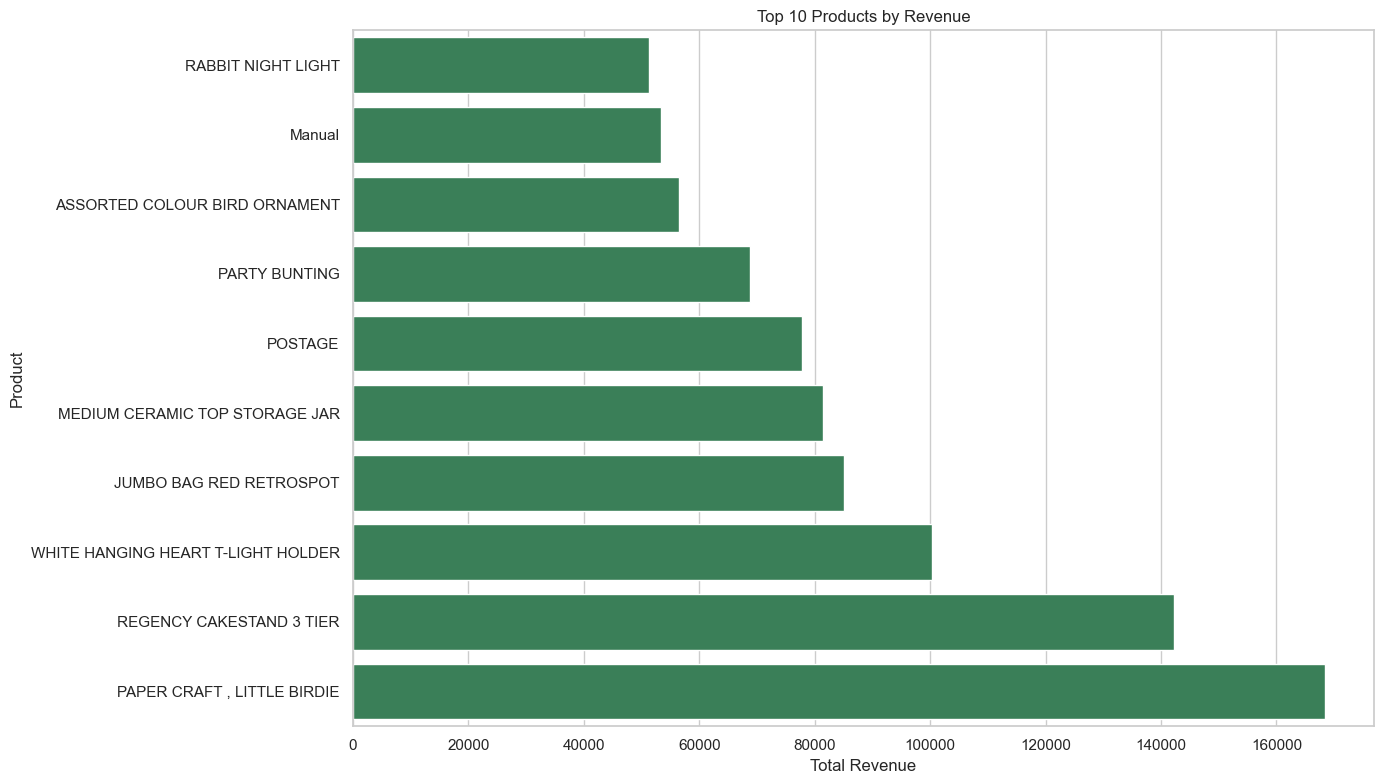

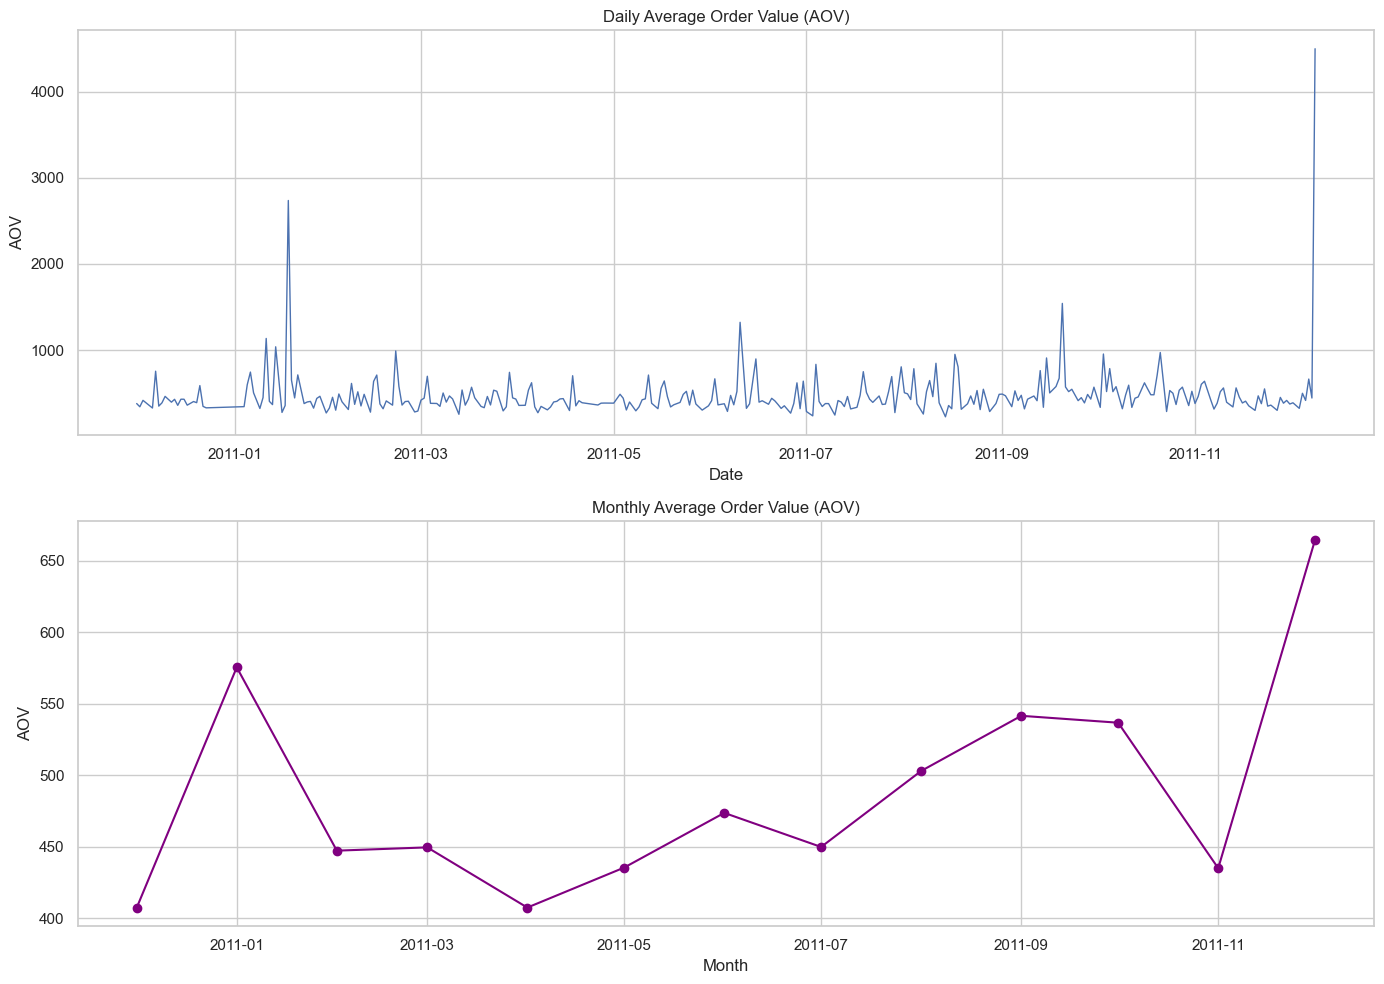

In [8]:
# Visualizations for key business questions

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1. Sales & revenue trends over time (line chart)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Monthly revenue trend
axes[0].plot(monthly_sales['InvoiceMonth'], monthly_sales['monthly_revenue'], marker='o')
axes[0].set_title('Monthly Revenue Over Time')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue')

# Monthly orders trend
axes[1].plot(monthly_sales['InvoiceMonth'], monthly_sales['monthly_orders'], marker='o', color='orange')
axes[1].set_title('Monthly Number of Orders Over Time')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

# 2. Geographic distribution (bar chart by country)

plt.figure(figsize=(14, 8))

geo_top = geo_summary.sort_values('total_revenue', ascending=False)

sns.barplot(
    data=geo_top,
    x='Country',
    y='total_revenue',
    color='steelblue'
)

plt.title('Total Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 3. Top 10 performing products (horizontal bar chart)

plt.figure(figsize=(14, 8))

top10 = top_10_products_by_revenue.copy()
top10 = top10.sort_values('total_revenue', ascending=True)

top10_labels = top10['Description'].fillna(top10['StockCode'])

sns.barplot(
    data=top10,
    x='total_revenue',
    y=top10_labels,
    orient='h',
    color='seagreen'
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

# 4. Average order value trend (line chart)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Daily AOV (smoothed visually by markers)
axes[0].plot(daily_aov['OrderDate_date'], daily_aov['AOV'], linewidth=1)
axes[0].set_title('Daily Average Order Value (AOV)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('AOV')

# Monthly AOV
axes[1].plot(monthly_aov['OrderMonth'], monthly_aov['AOV'], marker='o', color='purple')
axes[1].set_title('Monthly Average Order Value (AOV)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('AOV')

plt.tight_layout()
plt.show()

In [9]:
# Identify top product categories by revenue

# Derive a simple category from the first word in the Description
# (You can refine this later if needed.)

df_categories = df_clean.copy()
df_categories['Category'] = (
    df_categories['Description']
    .str.upper()
    .str.strip()
    .str.split()
    .str[0]
)

category_summary = df_categories.groupby('Category', dropna=False).agg(
    total_revenue=('Revenue', 'sum'),
    total_quantity=('Quantity', 'sum'),
    order_lines=('InvoiceNo', 'count'),
    unique_invoices=('InvoiceNo', 'nunique')
).reset_index().sort_values('total_revenue', ascending=False)

# Add share of total revenue per category
total_rev = category_summary['total_revenue'].sum()
category_summary['revenue_share_pct'] = 100 * category_summary['total_revenue'] / total_rev

# Show top 20 categories by revenue
print("=== TOP CATEGORIES BY REVENUE (BASED ON FIRST WORD OF DESCRIPTION) ===")
print(category_summary.head(20))

=== TOP CATEGORIES BY REVENUE (BASED ON FIRST WORD OF DESCRIPTION) ===
      Category  total_revenue  total_quantity  order_lines  unique_invoices  \
660        SET      530800.01          277009        25743             9007   
400      JUMBO      489317.21          259662        14198             4178   
614        RED      322670.75          165663        14056             7305   
537      PAPER      311187.85          138025         4275             2781   
240    DOORMAT      293996.64           46522         6741             2929   
444      LUNCH      233752.66          144292        12248             3911   
616    REGENCY      227406.23           43919         3924             2171   
787    VINTAGE      203205.75           82111         8178             4658   
800      WHITE      163080.12           67843         5363             4070   
564       PINK      133327.48           81903         7060             4612   
526       PACK      129838.90          240645        10231  

In [11]:
import pandas as pd

# Load dataset
# (Assumes 'Online Retail.xlsx' is in the same folder as this notebook.)
df = pd.read_excel('Online Retail.xlsx')

# --- Data cleaning (aligned with earlier analysis) ---

# Work on a copy
df_clean = df.copy()

# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# Keep rows with a valid customer ID
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove cancelled invoices (InvoiceNo starting with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Keep only positive quantities and unit prices
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Create Revenue column
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# --- RFM calculation ---

# Snapshot date: one day after the last invoice date
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Aggregate RFM metrics per customer
rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

# Compute quantiles for R, F, M
quantiles = rfm[['Recency', 'Frequency', 'Monetary']].quantile(
    [0.2, 0.4, 0.6, 0.8]
).to_dict()

# Helper functions to score R, F, and M

def r_score(x):
    """Smaller recency (more recent) = better, so higher score."""
    if x <= quantiles['Recency'][0.2]:
        return 5
    elif x <= quantiles['Recency'][0.4]:
        return 4
    elif x <= quantiles['Recency'][0.6]:
        return 3
    elif x <= quantiles['Recency'][0.8]:
        return 2
    else:
        return 1

def fm_score(x, col):
    """Larger frequency/monetary = better, so higher score."""
    if x <= quantiles[col][0.2]:
        return 1
    elif x <= quantiles[col][0.4]:
        return 2
    elif x <= quantiles[col][0.6]:
        return 3
    elif x <= quantiles[col][0.8]:
        return 4
    else:
        return 5

# Apply scores
rfm['R_Score'] = rfm['Recency'].apply(r_score)
rfm['F_Score'] = rfm['Frequency'].apply(lambda x: fm_score(x, 'Frequency'))
rfm['M_Score'] = rfm['Monetary'].apply(lambda x: fm_score(x, 'Monetary'))

# Combined RFM score as a string (e.g., '555', '421')
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

print("=== RFM HEAD ===")
print(rfm.head())
print("\nRFM shape:", rfm.shape)
print("\nRFM score distribution:")
print(rfm['RFM_Score'].value_counts().sort_index())

=== RFM HEAD ===
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0     12346.0      326          1  77183.60        1        1        5   
1     12347.0        2          7   4310.00        5        5        5   
2     12348.0       75          4   1797.24        2        4        4   
3     12349.0       19          1   1757.55        4        1        4   
4     12350.0      310          1    334.40        1        1        2   

  RFM_Score  
0       115  
1       555  
2       244  
3       414  
4       112  

RFM shape: (4338, 8)

RFM score distribution:
RFM_Score
111    331
112    206
113     59
114     21
115      4
      ... 
545     61
551      1
553      1
554     59
555    323
Name: count, Length: 113, dtype: int64
